# California 房价预测实战

本 notebook 记录了从数据读取、特征工程、模型训练到提交文件生成的完整流程。
核心目标：在保证训练稳定性的前提下，提升线上评分表现，并避免预测值异常堆积（如大量 1.0）。

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l
from pathlib import Path
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


def resolve_existing_path(path_candidates):
    for p in path_candidates:
        p = Path(p)
        if p.exists() and p.is_file():
            return p
    raise FileNotFoundError(
        "未找到数据文件，请检查路径。尝试过:\n" + "\n".join(str(Path(p)) for p in path_candidates)
    )

train_data = pd.read_csv(r"C:\Users\，\Downloads\train.csv\train.csv")
test_data = pd.read_csv(r"C:\Users\，\Downloads\test.csv\test.csv")


print(train_data.shape)
print(test_data.shape)

print(train_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]]) 
print(test_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]])

C:\Users\，\AppData\Local\Temp\ipykernel_22288\371095027.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


(47439, 41)
(31626, 40)
   Id            Address  Sold Price  \
0   0        540 Pine Ln   3825000.0   
1   1     1727 W 67th St    505000.0   
2   2     28093 Pine Ave    140000.0   
3   3  10750 Braddock Dr   1775000.0   

                                             Summary         City    Zip State  
0  540 Pine Ln, Los Altos, CA 94022 is a single f...    Los Altos  94022    CA  
1  HURRY, HURRY.......Great house 3 bed and 2 bat...  Los Angeles  90047    CA  
2  'THE PERFECT CABIN TO FLIP!  Strawberry deligh...   Strawberry  95375    CA  
3  Rare 2-story Gated 5 bedroom Modern Mediterran...  Culver City  90230    CA  
      Id                    Address  \
0  47439        3034 N Coolidge Ave   
1  47440         565 Kenilworth Ave   
2  47441        3028 N Coolidge Ave   
3  47442  3022 N North Coolidge Ave   

                                             Summary          Type  \
0  Live within steps to the scenic views on the L...  SingleFamily   
1                 duplex fixer. In

## 1. 数据读取与环境准备

这一段完成：
- 基础库导入（numpy/pandas/torch/d2l）
- 数据路径读取
- 训练集与测试集形状检查
- 样本字段快速预览

这里也保留了 `KMP_DUPLICATE_LIB_OK` 作为环境兼容兜底，用于缓解 OpenMP 冲突。

In [ ]:
from collections import Counter
import unicodedata


def count_comma(s):
    """统计字符串中逗号的个数"""
    dic = Counter(s)
    return dic[',']


def is_number(s):
    """判断是否为数字"""
    try:
        float(s)
        return True
    except ValueError:
        pass
    
    try:
        unicodedata.numeric(s)
        return True
    except (TypeError, ValueError):
        pass
    
    return False


def comma_to_number(features, cols_list):
    """
    将文字描述统一处理为数量（根据逗号个数+1确定）：
1. 只处理指定列表中的数据
2. 无法解析的保留为 NaN
    """
    X = features.copy()
    for col in cols_list:
        for i, item in enumerate(X[col]):
            if not is_number(item):
                X.loc[i, col] = count_comma(item) + 1
        X[col] = X[col].astype('float')
    return X

def time_cols_to_year(features, time_cols):
    """
    对时间列做年份提取：
    1. 只取前四位年份
    2. 不做最小值平移
    3. 无法解析的保留为 NaN

    Args:
        features: pandas.DataFrame
        time_cols: list[str]，要处理的时间列名列表

    Returns:
        处理后的 DataFrame（副本）
    """
    X = features.copy()
    for col in time_cols:
        if col in X.columns:
            # 先转字符串取前4位，再转数值；无法转换的变为 NaN
            X[col] = pd.to_numeric(X[col].astype(str).str[:4], errors="coerce")
    return X

def multi_hot_int(df, cols, sep=","):
    X = df.copy()
    for col in cols:
        if col not in X.columns:
            continue

        s = (
            X[col]
            .fillna("")
            .astype(str)
            .str.replace(r"\s*,\s*", sep, regex=True)
            .str.strip(sep + " ")
        )
        
        dummies = s.str.get_dummies(sep=sep).astype(bool)
        
        if "" in dummies.columns:
            dummies = dummies.drop(columns=[""])

        dummies = dummies.add_prefix(f"{col}_")
        X = X.drop(columns=[col]).join(dummies)

    return X

## 2. 文本与时间特征处理函数

这一段定义了多类预处理函数：
- 文本计数转数值（如逗号分隔字段）
- 时间字段提取年份
- 多标签字段做 multi-hot 展开

这些函数用于把原始字符串特征转换成可训练的数值/布尔特征。

In [3]:
TARGET = "Sold Price"
TIME_COLUMNS = ['Listed On', 'Last Sold On']
TYPE_COLUMNS = ['Appliances included','Heating', 'Cooling', 'Flooring', 'Heating features', 'Cooling features', 'Laundry features', 'Appliance Included', 'Parking features']
DROP_COLUMNS = ["Id",'State','City',"Summary", "Address", 'Elementary School', 'Middle School', 'High School']
room_cols = ['Bedrooms', 'Parking']


y_train = train_data[TARGET]
X_train = comma_to_number(
    time_cols_to_year(
        multi_hot_int(
            train_data.drop(columns=DROP_COLUMNS + [TARGET]), 
                    TYPE_COLUMNS),
                    TIME_COLUMNS),
                    room_cols)
X_test = comma_to_number(
    time_cols_to_year(
        multi_hot_int(
            test_data.drop(columns=DROP_COLUMNS),
                     TYPE_COLUMNS),
                     TIME_COLUMNS),
                     room_cols)  
# 找到共同列（交集）
common_cols = X_train.columns.intersection(X_test.columns)

# 仅用于查看被删掉了哪些列
only_in_train = X_train.columns.difference(X_test.columns)
only_in_test = X_test.columns.difference(X_train.columns)

print(f"仅训练集有的列: {len(only_in_train)}")
print(f"仅测试集有的列: {len(only_in_test)}")

# 删除不一致列，只保留共同列
X_train = X_train.loc[:, common_cols].copy()
X_test = X_test.loc[:, common_cols].copy()

print("对齐后形状:", X_train.shape, X_test.shape)

仅训练集有的列: 177
仅测试集有的列: 118
对齐后形状: (47439, 686) (31626, 686)


## 3. 特征列配置与训练/测试集构造

这一段做了三件事：
- 明确目标列 `Sold Price`
- 指定需要删除、时间处理、多标签处理的列
- 生成 `X_train/X_test` 与 `y_train`

关键点：训练特征里已显式剔除目标列，避免标签泄露。

In [4]:
all_features = pd.concat((X_train.iloc[:, :], X_test.iloc[:, :]))
print(X_train['Parking features_Uncovered'].dtype)

bool


In [5]:
numeric_features = all_features.dtypes[
    (all_features.dtypes != "object") & (all_features.dtypes != "bool")
].index
bool_features = all_features.dtypes[all_features.dtypes == "bool"].index
object_features = all_features.dtypes[all_features.dtypes == "object"].index
# 删除 True 占比小于 5% 的稀有布尔特征
min_bool_ratio = 0.05
rare_bool_cols = [col for col in bool_features if all_features[col].mean() < min_bool_ratio]
all_features = all_features.drop(columns=rare_bool_cols)
print(f"删除稀有布尔列: {len(rare_bool_cols)}")
if rare_bool_cols:
    print("示例:", rare_bool_cols[:10])
object_features.shape[0], bool_features.shape[0], all_features[object_features]

删除稀有布尔列: 609
示例: ['Appliances included_6 Burner Stove', 'Appliances included_Barbecue', 'Appliances included_Built In Oven/Range', 'Appliances included_Built-In', 'Appliances included_Built-In Range', 'Appliances included_Convection Oven', 'Appliances included_Counter Top', 'Appliances included_Double Oven', 'Appliances included_ENERGY STAR Qualified Appliances', 'Appliances included_ENERGY STAR Qualified Water Heater']


(2,
 662,
                Type        Region
 0      SingleFamily     Los Altos
 1      SingleFamily   Los Angeles
 2      SingleFamily    Strawberry
 3      SingleFamily   Culver City
 4        VacantLand       Creston
 ...             ...           ...
 31621  SingleFamily       Truckee
 31622  SingleFamily     Oceanside
 31623    VacantLand       La Mesa
 31624     Townhouse     San Diego
 31625     Townhouse  Baldwin Park
 
 [79065 rows x 2 columns])

In [6]:
all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / (x.std()))
all_features[numeric_features] = all_features[numeric_features].fillna(0)
all_features = pd.get_dummies(all_features, columns=object_features, dummy_na=True, dtype=int)
all_features.shape

(79065, 1509)

In [7]:
all_features

,Year built,Parking,Lot,Bedrooms,Bathrooms,Full bathrooms,Total interior livable area,Total spaces,Garage spaces,Elementary School Score,...,Region_Yorkville,Region_Yosemite National Park,Region_Yountville,Region_Yreka,Region_Yuba City,Region_Yucaipa,Region_Yucca Valley,Region_Zamora,Region_Zenia,Region_nan
0,0.048505,0.348514,-0.018489,0.846659,-2.058002,0.000000,-0.006552,-0.135519,-0.123623,0.622758,...,0,0,0,0,0,0,0,0,0,0
1,-0.284656,-0.286472,-0.018287,0.053411,-0.336769,-0.106424,-0.005198,-0.062731,-0.050507,-1.308481,...,0,0,0,0,0,0,0,0,0,0
2,-0.036722,-0.921457,-0.018031,-0.739837,0.523848,-1.167570,-0.004763,-0.135519,-0.123623,0.000000,...,0,0,0,0,0,0,0,0,0,0
3,-0.121949,0.348514,0.000000,1.639906,0.523848,0.954722,-0.002493,-0.135519,-0.123623,1.588378,...,0,0,0,0,0,0,0,0,0,0
4,0.000000,-0.921457,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.139948,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31621,0.435902,2.253470,0.000000,1.639906,3.105697,0.000000,0.001650,-0.135519,0.095727,-0.342862,...,0,0,0,0,0,0,0,0,0,0
31622,0.056253,-0.286472,-0.018408,-0.739837,-0.336769,-1.167570,-0.005008,0.010056,-0.050507,-1.308481,...,0,0,0,0,0,0,0,0,0,0
31623,0.000000,-0.921457,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.105568,...,0,0,0,0,0,0,0,0,0,0
31624,0.164724,-0.921457,0.000000,0.053411,0.523848,-0.106424,-0.004334,0.010056,0.022610,0.622758,...,0,0,0,0,0,0,0,0,0,0


## 4. 数值标准化与独热编码

这里先对数值列做标准化，再统一缺失值填充，最后进行独热编码。
处理后特征维度会显著增加，这也是后续训练稳定性需要重点关注的原因。

In [8]:
print(all_features.dtypes.value_counts())
all_features = all_features.astype(np.float32)
print(all_features.dtypes.value_counts())

int32      1434
bool         53
float64      22
Name: count, dtype: int64
float32    1509
Name: count, dtype: int64


In [9]:
# ========== GPU 配置 ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA版本: {torch.version.cuda}")

train_features = torch.tensor(all_features[:X_train.shape[0]].values, dtype=torch.float32).to(device)
test_features = torch.tensor(all_features[X_train.shape[0]:].values, dtype=torch.float32).to(device)
train_labels = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32).to(device)

使用设备: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
CUDA版本: 13.0


## 5. 设备配置与张量化

将预处理后的特征转换为 `torch.tensor`，并迁移到 GPU/CPU。
这样后续训练循环可以直接使用同一设备上的数据进行前向与反向传播。

In [10]:
loss = nn.MSELoss()
in_features = train_features.shape[1]

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

def get_net():
    net = nn.Sequential(nn.Flatten(),
                        nn.Linear(in_features, layer1), 
                        nn.ReLU(), 
                        nn.Dropout(dropout1),
                        nn.Linear(layer1, 1)
                        
    )
    net.apply(init_weights)  # Xavier 初始化，降低深层网络训练不稳定风险
    return net.to(device)  # 将网络移到GPU/CPU

def log_rmse(net, features, labels):
    # 模型输出的是 log(price)，直接和 log(labels) 比较。
    labels_log = torch.log(torch.clamp(labels, 1, float('inf')))
    rmse = torch.sqrt(loss(net(features), labels_log))
    return rmse.item()

def train(net, train_features, train_labels, test_features, test_labels, 
          num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr = learning_rate,
                                 weight_decay = weight_decay)
    for epoch in range(num_epochs):
        net.train()
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)  # 确保批次也在GPU上
            optimizer.zero_grad()
            y_log = torch.log(torch.clamp(y, 1, float('inf')))
            l = loss(net(X), y_log)
            l.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
            optimizer.step()

        net.eval()
        with torch.no_grad():
            train_ls.append(log_rmse(net, train_features, train_labels))
            if test_labels is not None:
                test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

## 6. 模型定义与训练函数

这一段包含：
- 两层全连接网络 + Dropout
- Xavier 权重初始化
- 对数空间训练（优化 `log(price)`）
- 梯度裁剪（防止梯度爆炸）

这部分是本 notebook 的稳定性核心改动。

In [11]:
def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat((X_train, X_part), dim=0)
            y_train = torch.cat((y_train, y_part), dim=0)
    return X_train, y_train, X_valid, y_valid

def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay, batch_size):
    train_l_sum, valid_l_sum = 0.0, 0.0
    for i in range(k): 
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate,
                                   weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                     legend=['train', 'valid'], yscale='log')
        print(f'折{i + 1}, 平均训练log rmse: {train_ls[-1]:f}, '
              f'平均验证log rmse: {valid_ls[-1]:f}')
    return train_l_sum / k, valid_l_sum / k

## 7. K 折交叉验证

通过 K 折划分评估模型泛化能力，并输出每折的训练/验证 log rmse。
这里用于挑选超参数组合，避免只看单次训练结果。

折1, 平均训练log rmse: 0.224351, 平均验证log rmse: 0.235369
折2, 平均训练log rmse: 0.240864, 平均验证log rmse: 0.238183
折3, 平均训练log rmse: 0.275609, 平均验证log rmse: 0.275968
折4, 平均训练log rmse: 0.236687, 平均验证log rmse: 0.286884
折5, 平均训练log rmse: 0.230521, 平均验证log rmse: 0.694474
5-折验证: 平均训练log rmse: 0.241607, 平均验证log rmse: 0.346175


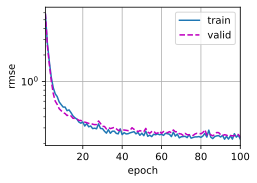

In [20]:
torch.manual_seed(42)
np.random.seed(42)

# ========== 参数推荐 ==========
# 对数空间训练后，学习率可先保守一些避免不稳定。
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 2e-4 ,5e-4, 256
dropout1, dropout2 = 0.3, 0.2  # 15K维特征需要更强的正则化
layer1, layer2 = 512, 64

train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                          weight_decay, batch_size)

print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, '
      f'平均验证log rmse: {float(valid_l):f}')

## 8. 超参数设置与验证结果

本段设置随机种子和训练超参数，并执行 K 折验证。
当前参数在稳定性和收敛速度之间做了折中。

In [21]:
def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
             ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    print(f'训练log rmse：{float(train_ls[-1]):f}')

    # 将网络应用于测试集，先输出 log(price)，再还原到 price。
    net.eval()
    with torch.no_grad():
        log_preds = net(test_features)
        preds = torch.exp(log_preds).detach().cpu().numpy()

    preds = np.maximum(preds, 1.0)
    test_data['Sold Price'] = pd.Series(preds.reshape(-1))
    submission = pd.concat([test_data['Id'], test_data['Sold Price']], axis=1)
    submission.to_csv('submission_Calif.csv', index=False)

## 9. 全量训练与提交文件生成

使用全部训练数据训练后，对测试集推理并导出 `submission_Calif.csv`。
注意：模型输出在对数空间，推理时已做 `exp` 还原到价格空间。

训练log rmse：0.242728


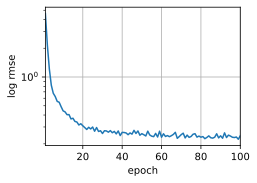

In [22]:
train_and_pred(train_features, test_features, train_labels, test_data,
               num_epochs, lr, weight_decay, batch_size)

## 10. 问题记录（本次迭代）

本次训练与提交流程中遇到的主要问题：
- 内核重启后直接运行后续单元，导致 `torch` 未定义。
- 环境中出现 OpenMP 冲突（`libiomp5md.dll` 重复初始化），导致 kernel 崩溃。
- 推理时将 CUDA tensor 直接转 numpy，引发设备类型错误。
- 训练目标与评估目标最初不一致，出现大量预测值被截断为 `1.0`，线上分数异常偏高。

对应处理：
- 统一从前往后顺序执行单元。
- 增加环境兼容兜底并检查包冲突来源。
- 推理阶段使用 `.detach().cpu().numpy()`。
- 改为对数空间训练，并在推理阶段 `exp` 还原价格。
- 增加 Xavier 初始化与梯度裁剪，降低训练不稳定风险。